<div class="alert alert-block alert-warning">
<span style="color: rgb(0,53,91);">
<font face = "Times New Roman" size = "6"><b><center>Maestría en Ciencia de datos</center></b></font>
<font face = "Times New Roman" size = "5"><b><center>PROGRAMACION PARA ANALISIS DE DATOS</center></b></font>
<font face = "Times New Roman" size = "5"><center>Predicción de demanda diaria mediante SARIMAX y optimización convexa de inventario para minimizar faltantes y exceso de stock.</center></font></b>
<font face = "Times New Roman" size = "5"><center>Alumno: Jorge Eduardo Esesarte Rodriguez</center></font></b>
<div align="right"><font face = "Times New Roman" size = "2">Maestro: Pedro Martinez Gutierrez</font></div>
</span></div>

## Contexto y Problemática
La sucursal centro de Comex en Ciudad Guzman enfrenta desafíos debido a la variabilidad en el cumplimiento de proveedores y la incertidumbre en la demanda de los clientes. Actualmente, las ineficiencias en el proceso de reabastecimiento derivan en errores en la recepción de pedidos o incumplimientos por parte de terceros, lo que se traduce en ventas perdidas por falta de inventario de tabla roca.

## Objetivo del Proyecto
El objetivo central es desarrollar un modelo integrado que combine predicción de demanda y optimización convexa para determinar niveles óptimos de inventario. Para ello, se utiliza un modelo SARIMA con hiperparámetros optimizados para estimar la demanda futura, y posteriormente se incorpora dicha demanda predicha en un modelo convexo que minimiza los costos de almacenamiento y desabasto bajo restricciones operativas y financieras.

## 1. Descripción del dataset

El dataset, proporcionado por la gerencia del establecimiento, registra **4,554 movimientos de inventario** distribuidos en 13 columnas con información técnica y logística. A continuación, se detallan las variables que componen el conjunto de datos:

1. `Movimiento`: Identificador numérico asignado a la categoría de la operación.
2. `Fecha`: Registro del día del movimiento en formato `AAAA/MM/DD`.
3. `Hora`: Registro del tiempo exacto en que se ejecutó la transacción.
4. `Cantidad`: Número de unidades movilizadas en la operación.
5. `Existencia`: Stock remanente en inventario tras la ejecución del movimiento.
6. `Costo`: Precio unitario de adquisición del material.
7. `Costo promocional`: Valor de costo aplicado bajo condiciones de promoción.
8. `Precio`: Valor de venta al público asignado al material.
9. `Referencia 1`: Primer identificador (nombre) del usuario que registró el movimiento.
10. `Referencia 2`: Segundo identificador del usuario asociado a la transacción.
11. `Doctono`: Folio o número de documento de soporte.
12. `Observaciones`: Descripción textual del tipo de movimiento realizado (e.g., Ticket, Traspaso).
13. `Secuencial`: Valor incremental que determina el orden cronológico único de los registros.
14. `Nombre`: Nombre completo del personal responsable de la operación.

Con esta informacion se busca optimizar la cantidad de invetario que la tienda debe de tener para minimizar las perdidas por falta de inventario.

Para resolver el problema planteado se utilizaran las siguintes columnas:
1) `Fecha`
2) `Cantidad`
3) `Existencia`
4) `Costo`
5) `Precio`
6) `Observaciones`

Ahora se descragan las librerias que se utilizaran y se realiza la lectura del DataSet desde un archivo XLS y se guarda en un DataFrame de Pandas:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cvxpy as cp
import itertools
import warnings

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")

df = pd.read_excel("plaka.xls")
display(df)

WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero


,MOV,FECHA,HORA,CANTIDAD,EXIST,COSTO,COSTOPROM,PRECIO,REF1,REF2,DOCTONO,OBSERVACIONES,SECUENCIAL,NOMBRE
0,10,2019-12-30,10:45 a. m.,4.0,-67.0,90.48,NaN,121.0,ADRIAN,ALFREDO,8606,TRASPASO DE SALIDA,15.0,ALFREDO
1,10,2019-12-30,12:07 p. m.,1.0,-68.0,90.48,NaN,121.0,ARTURO,ALFREDO,8609,TRASPASO DE SALIDA,11.0,ALFREDO
2,3,2019-12-30,02:32 p. m.,1.0,-69.0,78.00,0.0,110.0,CAJA 01,NaN,58563,TICKET,1.0,LUPE
3,3,2019-12-30,05:04 p. m.,1.0,-70.0,78.00,0.0,110.0,CAJA 01,NaN,58572,TICKET,1.0,ALFREDO
4,5,2020-01-03,04:22 p. m.,10.0,-80.0,78.00,NaN,103.0,23,FACTURA,29039,FACTURA,1.0,JOSE LUIS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4549,3,2026-02-27,12:39 p. m.,2.0,242.0,123.50,0.0,186.0,CAJA 01,NaN,113366,TICKET,1.0,DANIEL CIBRIAN
4550,4,2026-02-27,03:08 p. m.,20.0,222.0,123.50,0.0,186.0,CAJA 99,NaN,29992,TICK,3.0,ALFREDO
4551,10,2026-02-27,07:17 p. m.,13.0,209.0,143.26,NaN,196.0,ALFREDO,ADRIAN,16693,TRASPASO DE SALIDA,1.0,ALFREDO
4552,10,2026-02-27,07:17 p. m.,2.0,207.0,143.26,NaN,196.0,ALFREDO,ADRIAN,16693,TRASPASO DE SALIDA,11.0,ALFREDO


## 2. Limpieza del dataframe

Se define la columna 'OBSERVACIONES' como el índice del DataFrame, ya que constituye la variable clave para categorizar los movimientos de inventario y filtrar las transacciones de venta. Posteriormente, se eliminan las variables que no aportan valor al proyecto de optimización, y se normaliza el nombre de las columnas para asegurar la consistencia.

In [2]:
df = pd.read_excel("plaka.xls", index_col = 'OBSERVACIONES')

columnas_a_eliminar = ['MOV', 'HORA', 'REF1', 'REF2', 'DOCTONO', 'SECUENCIAL', "NOMBRE", "COSTOPROM"]
df.drop(columns=columnas_a_eliminar, inplace=True)

df = df.rename(columns={'EXIST': 'EXISTENCIA'})

display(df)

WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero


,FECHA,CANTIDAD,EXISTENCIA,COSTO,PRECIO
OBSERVACIONES,,,,,
TRASPASO DE SALIDA,2019-12-30,4.0,-67.0,90.48,121.0
TRASPASO DE SALIDA,2019-12-30,1.0,-68.0,90.48,121.0
TICKET,2019-12-30,1.0,-69.0,78.00,110.0
TICKET,2019-12-30,1.0,-70.0,78.00,110.0
FACTURA,2020-01-03,10.0,-80.0,78.00,103.0
...,...,...,...,...,...
TICKET,2026-02-27,2.0,242.0,123.50,186.0
TICK,2026-02-27,20.0,222.0,123.50,186.0
TRASPASO DE SALIDA,2026-02-27,13.0,209.0,143.26,196.0


El gerente de la tienda especifico que únicamente los registros etiquetados como 'FACTURA' y 'TICKET' representan ventas efectivas. Por lo que se busca solo tomar en cuenta esos datos. Se realiza un análisis de los valores únicos en el índice 'OBSERVACIONES':

In [3]:
print(df.index.unique())

Index(['TRASPASO DE SALIDA', 'TICKET', 'FACTURA', 'TRASPASO DE ENTRADA ',
       'DEVOLUCION A TICKET', 'NOTA DE SALIDA', 'TICK', 'CANCELACION DE FACTU',
       'INVENTARIO FISICO', 'CANCELACION DE TRASP', 'NOTA DE ENTRADA',
       'CAPTURA COMPRA REMOT', 'COMPRA', 'INICIALIZA'],
      dtype='object', name='OBSERVACIONES')


Tras la inspección, se detectó una inconsistencia en el registro de datos (entradas etiquetadas erróneamente como 'TICK'). Se procede a renombrar estas incosistencias y, posteriormente, se aplica un filtro para conservar las categorías de interés.

In [4]:
total_tick = (df.index == 'TICK').sum()
print(f"Hay {total_tick} entradas etiquetadas como 'TICK'")

df.index = df.index.str.upper().map(lambda x: 'TICKET' if x == 'TICK' else x)

df = df.loc[df.index.isin(['FACTURA', 'TICKET'])]

display(df)

Hay 216 entradas etiquetadas como 'TICK'


,FECHA,CANTIDAD,EXISTENCIA,COSTO,PRECIO
OBSERVACIONES,,,,,
TICKET,2019-12-30,1.0,-69.0,78.0,110.0
TICKET,2019-12-30,1.0,-70.0,78.0,110.0
FACTURA,2020-01-03,10.0,-80.0,78.0,103.0
FACTURA,2020-01-06,11.0,-22.0,78.0,110.0
FACTURA,2020-01-06,11.0,-33.0,78.0,110.0
...,...,...,...,...,...
TICKET,2026-02-27,2.0,281.0,123.5,186.0
TICKET,2026-02-27,21.0,260.0,123.5,186.0
TICKET,2026-02-27,16.0,244.0,123.5,186.0


In [5]:
df.describe(include='all')

,FECHA,CANTIDAD,EXISTENCIA,COSTO,PRECIO
count,3249,3249.000000,3249.000000,3249.000000,3249.000000
mean,2023-02-15 20:02:52.853185792,9.468760,179.841951,88.606784,150.020363
min,2019-12-30 00:00:00,1.000000,-882.000000,78.000000,18.000000
25%,2021-08-10 00:00:00,2.000000,-107.000000,78.000000,122.000000
50%,2023-01-24 00:00:00,5.000000,113.000000,78.000000,145.000000
75%,2024-08-31 00:00:00,10.000000,240.000000,104.820000,174.000000
max,2026-02-27 00:00:00,980.000000,11569.000000,123.560000,196.000000
std,NaN,38.265261,1054.716756,17.568574,27.217094


Se revisa si el DataFrame contiene datos nulos.

In [6]:
print(df.reset_index().isnull().sum())

OBSERVACIONES    0
FECHA            0
CANTIDAD         0
EXISTENCIA       0
COSTO            0
PRECIO           0
dtype: int64


## 3. Optimización convexa

Mediante los cuatro pasos para la optimización convexa se busca llegar a la creacion de un modelo de predicción que pueda ayudar a optimizar el inventario de la tienda.

1) Establecer variables objetivo
2) Establecer función objetivo
3) Establecer restricciones
4) Generar modelo

# Variable objetivo

La variable de decisión es $x_t$

Sea $x_t$ la cantidad óptima de inventario a mantener durante el periodo $t$. El objetivo del modelo es determinar este valor para equilibrar los costos operativos.

# Función Objetivo
El modelo busca minimizar el costo total esperado, compuesto por el almacenamiento y el costo de oportunidad por ventas perdidas:$$\min_{x_t} \sum_{t} [c_h(x_t - \hat{d}_t)^+ + c_s(\hat{d}_t - x_t)^+]$$
Donde:
* $\hat{d}_t$: Demanda estimada para el periodo.
* $c_h$: Costo unitario de mantenimiento.
* $c_s$: Costo unitario por desabasto.
* $(\cdot)^+$: Operador de parte positiva, asegura que el costo sea no-negativo.

# Restricciones Operativas
1. Existencia física: $x_t \geq 0$
2. Capacidad de bodega: $x_t \leq C$, donde $C$ es el límite de almacenamiento.
3. Límite financiero: $p_t x_t \leq B$, donde $p_t$ es el costo de adquisición y $B$ el presupuesto asignado.

## Generar el modelo mediante cvxpy

Primero se crea una copia del dataframe original para evitar modificar directamente los datos fuente. Después, las variables FECHA, CANTIDAD, EXISTENCIA, COSTO y PRECIO son convertidas a formatos adecuados. Posteriormente, se filtran únicamente los registros correspondientes a ventas reales, es decir, aquellos identificados como TICKET y FACTURA. A continuación, los datos se agrupan por fecha para construir una serie de demanda diaria, calculando la demanda total vendida, el costo promedio, el precio promedio y la última existencia registrada de cada día. Los datos resultantes se ordenan cronológicamente y se guarda una copia de la demanda original antes de aplicar un proceso de suavizado mediante winsorización superior utilizando el percentil 99, con el objetivo de reducir el impacto de valores extremos u outliers sobre el modelo de optimización.

In [7]:
df = df.copy()

df["FECHA"] = pd.to_datetime(df["FECHA"])
df["CANTIDAD"] = pd.to_numeric(df["CANTIDAD"], errors="coerce")
df["EXISTENCIA"] = pd.to_numeric(df["EXISTENCIA"], errors="coerce")
df["COSTO"] = pd.to_numeric(df["COSTO"], errors="coerce")
df["PRECIO"] = pd.to_numeric(df["PRECIO"], errors="coerce")


ventas = df[df.index.isin(["TICKET", "FACTURA"])].copy()

demanda_diaria = (
    ventas.groupby("FECHA")
    .agg(
        demanda=("CANTIDAD", "sum"),
        costo_unitario=("COSTO", "mean"),
        precio_unitario=("PRECIO", "mean"),
        existencia=("EXISTENCIA", "last")
    )
    .reset_index()
)

demanda_diaria = demanda_diaria.sort_values("FECHA")

demanda_diaria["demanda_original"] = demanda_diaria["demanda"]

limite = demanda_diaria["demanda"].quantile(0.99)

demanda_diaria["demanda"] = np.clip(
    demanda_diaria["demanda"],
    None,
    limite
)

demanda_diaria.head()

,FECHA,demanda,costo_unitario,precio_unitario,existencia,demanda_original
0,2019-12-30,2.0,78.0,110.0,-70.0,2.0
1,2020-01-03,10.0,78.0,103.0,-80.0,10.0
2,2020-01-06,38.0,78.0,110.0,-49.0,38.0
3,2020-01-07,1.0,78.0,121.0,-50.0,1.0
4,2020-01-08,2.0,78.0,110.0,-52.0,2.0


Se definen los parámetros principales utilizados en el modelo de optimización convexa. Se define el costo de almacenamiento $c_h$ como el 5% del costo unitario del producto, mientras que el costo de desabasto $c_s$ se calcula como la diferencia entre el precio de venta y el costo unitario, representando una aproximación de la pérdida asociada a no satisfacer demanda.
Finalmente, se establecen las restricciones principales del modelo: la capacidad máxima del almacén (C) se define como el percentil 95 de la demanda diaria suavizada para evitar sobredimensionar el inventario por eventos extremos, y el presupuesto total (B) se calcula como el costo agregado necesario para cubrir la demanda histórica observada considerando los costos unitarios promedio.

In [8]:
d_hat = demanda_diaria["demanda"].values
p_t = demanda_diaria["costo_unitario"].values
precio = demanda_diaria["precio_unitario"].values

n = len(d_hat)

ch = 0.05 * p_t
cs = precio - p_t

cs = np.maximum(cs, 0)

C = demanda_diaria["demanda"].quantile(0.95)
B = np.sum(p_t * d_hat)

Se construye el modelo de optimización convexa utilizando la librería CVXPY. Primero, se define la variable de decisión x, que representa la cantidad óptima de inventario para cada periodo analizado. Posteriormente, se calculan los costos de almacenamiento mediante cp.pos(x - d_hat), los cuales penalizan el exceso de inventario respecto a la demanda estimada, y los costos de desabasto mediante cp.pos(d_hat - x), que penalizan los faltantes cuando la demanda supera el inventario disponible. Ambos costos son ponderados por sus respectivos parámetros $c_h$ y $c_s$. Después, se define la función objetivo como la minimización de la suma total de dichos costos. Finalmente, se crea y resuelve el problema de optimización, obteniendo el estado de la solución y el costo total óptimo alcanzado por el modelo.

In [9]:
x = cp.Variable(n)

holding_cost = cp.multiply(ch, cp.pos(x - d_hat))
shortage_cost = cp.multiply(cs, cp.pos(d_hat - x))

objective = cp.Minimize(cp.sum(holding_cost + shortage_cost))

constraints = [
    x >= 0,
    x <= C,
    cp.sum(cp.multiply(p_t, x)) <= B
]

problem = cp.Problem(objective, constraints)
problem.solve()

print("Estado del modelo:", problem.status)
print("Costo óptimo:", problem.value)

Estado del modelo: optimal
Costo óptimo: 175767.7984484827


Se almacena y analiza los resultados obtenidos por el modelo de optimización convexa. Primero, se guarda en el dataframe el inventario óptimo calculado por CVXPY para cada periodo. Posteriormente, se calculan el exceso de inventario y el faltante comparando el inventario óptimo con la demanda observada; el exceso representa unidades sobrantes almacenadas, mientras que el faltante representa demanda no satisfecha. Después, se estiman los costos de almacenamiento y desabasto multiplicando dichos excesos y faltantes por sus respectivos costos unitarios $c_h$ y $c_s$. Finalmente, se calcula el costo total por periodo como la suma de ambos componentes y se muestran las primeras filas del dataframe para verificar los resultados generados por el modelo.

In [10]:
demanda_diaria["inventario_optimo"] = x.value
demanda_diaria["exceso_inventario"] = np.maximum(demanda_diaria["inventario_optimo"] - demanda_diaria["demanda"], 0)
demanda_diaria["faltante"] = np.maximum(demanda_diaria["demanda"] - demanda_diaria["inventario_optimo"], 0)

demanda_diaria["costo_almacenamiento"] = ch * demanda_diaria["exceso_inventario"]
demanda_diaria["costo_desabasto"] = cs * demanda_diaria["faltante"]

demanda_diaria["costo_total"] = (
    demanda_diaria["costo_almacenamiento"] +
    demanda_diaria["costo_desabasto"]
)

demanda_diaria.head()

,FECHA,demanda,costo_unitario,precio_unitario,existencia,demanda_original,inventario_optimo,exceso_inventario,faltante,costo_almacenamiento,costo_desabasto,costo_total
0,2019-12-30,2.0,78.0,110.0,-70.0,2.0,2.0,2.738197e-09,0.0,1.067897e-08,0.0,1.067897e-08
1,2020-01-03,10.0,78.0,103.0,-80.0,10.0,10.0,2.822109e-09,0.0,1.100622e-08,0.0,1.100622e-08
2,2020-01-06,38.0,78.0,110.0,-49.0,38.0,38.0,2.951651e-09,0.0,1.151144e-08,0.0,1.151144e-08
3,2020-01-07,1.0,78.0,121.0,-50.0,1.0,1.0,2.855000e-09,0.0,1.113450e-08,0.0,1.113450e-08
4,2020-01-08,2.0,78.0,110.0,-52.0,2.0,2.0,2.738196e-09,0.0,1.067897e-08,0.0,1.067897e-08


Se genera un DF con las principales metricas obtenidas.

In [11]:
resumen = pd.DataFrame({
    "Métrica": [
        "Costo total óptimo",
        "Inventario óptimo promedio",
        "Demanda promedio",
        "Faltante promedio",
        "Exceso promedio",
        "Presupuesto utilizado"
    ],
    "Valor": [
        problem.value,
        demanda_diaria["inventario_optimo"].mean(),
        demanda_diaria["demanda"].mean(),
        demanda_diaria["faltante"].mean(),
        demanda_diaria["exceso_inventario"].mean(),
        np.sum(p_t * demanda_diaria["inventario_optimo"])
    ]
})

resumen["Valor"] = resumen["Valor"].round(2)
resumen

,Métrica,Valor
0,Costo total óptimo,175767.80
1,Inventario óptimo promedio,15.64
2,Demanda promedio,17.54
3,Faltante promedio,1.90
4,Exceso promedio,0.00
5,Presupuesto utilizado,2042441.91


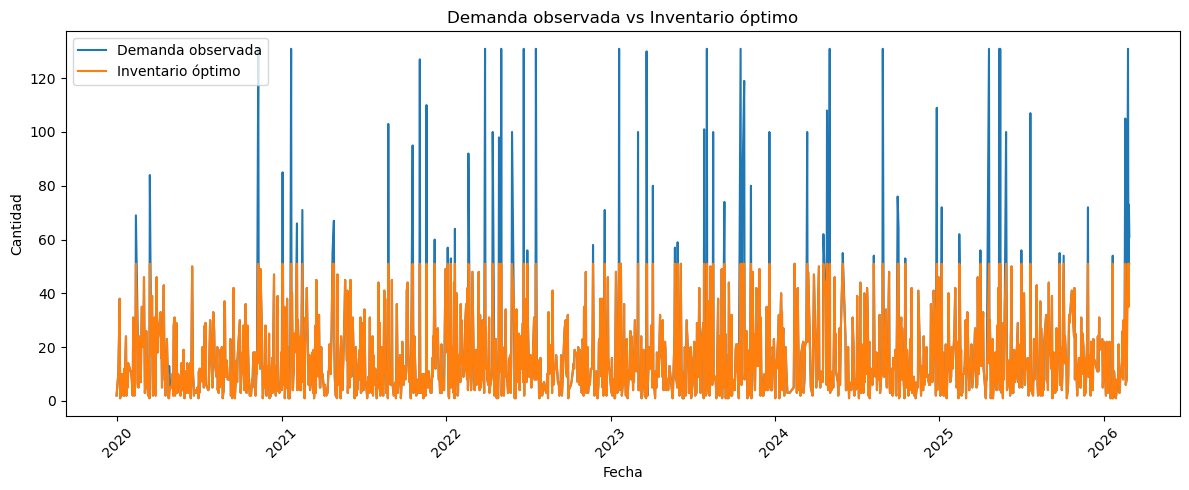

In [12]:
plt.figure(figsize=(12,5))
plt.plot(demanda_diaria["FECHA"], demanda_diaria["demanda"], label="Demanda observada")
plt.plot(demanda_diaria["FECHA"], demanda_diaria["inventario_optimo"], label="Inventario óptimo")
plt.xlabel("Fecha")
plt.ylabel("Cantidad")
plt.title("Demanda observada vs Inventario óptimo")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Modelo predictivo de demanda
La demanda diaria presenta comportamiento temporal y posible estacionalidad semanal/mensual, por lo que se considera utilziar un modelo SARIMA para capturar dependencias autorregresivas y patrones estacionales.

Se procede a preparar la serie de tiempo.

In [13]:
demanda_diaria = demanda_diaria.copy()

demanda_diaria["FECHA"] = pd.to_datetime(demanda_diaria["FECHA"])

demanda_diaria = demanda_diaria.sort_values("FECHA")

demanda_diaria = demanda_diaria.set_index("FECHA")

demanda_diaria = demanda_diaria.asfreq("D")

demanda_diaria["demanda"] = demanda_diaria["demanda"].fillna(0)

demanda_diaria["demanda_original"] = demanda_diaria["demanda_original"].fillna(0)

demanda_diaria["costo_unitario"] = demanda_diaria["costo_unitario"].ffill()

demanda_diaria["precio_unitario"] = demanda_diaria["precio_unitario"].ffill()

demanda_diaria["existencia"] = demanda_diaria["existencia"].ffill()

serie = demanda_diaria["demanda"]

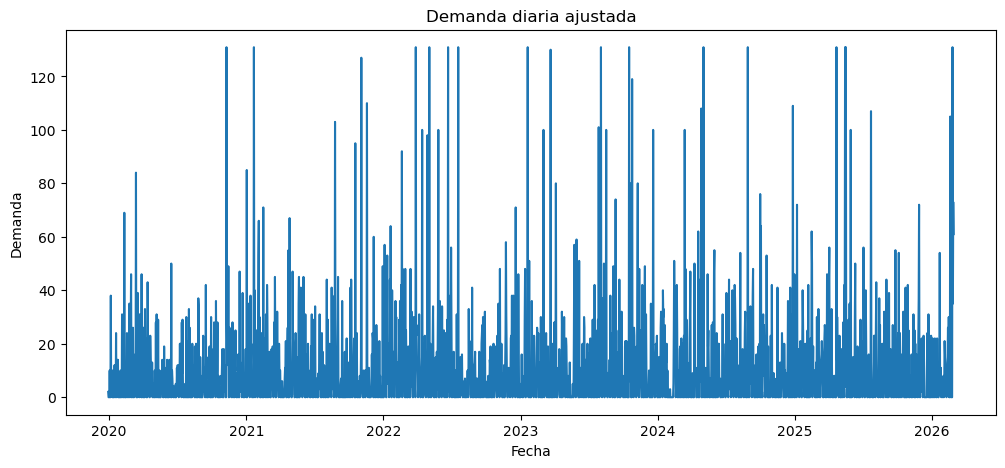

In [14]:
plt.figure(figsize=(12,5))
plt.plot(serie)
plt.title("Demanda diaria ajustada")
plt.xlabel("Fecha")
plt.ylabel("Demanda")
plt.show()

En esta sección se preparó la serie de tiempo de demanda diaria. La variable FECHA se convirtió a formato temporal y se estableció como índice del DataFrame para trabajar con frecuencia diaria. Los días sin ventas registradas se completaron con demanda igual a cero, mientras que las variables de costo, precio y existencia se rellenaron con el último valor observado. La gráfica muestra que la demanda diaria presenta alta variabilidad, con múltiples picos a lo largo del periodo analizado, lo que justifica el uso de modelos de series de tiempo para intentar capturar su comportamiento temporal.

In [15]:
from statsmodels.tsa.stattools import adfuller

resultado_adf = adfuller(serie.dropna())

print("Prueba Dickey-Fuller Aumentada")
print("Estadístico ADF:", resultado_adf[0])
print("p-value:", resultado_adf[1])
print("Valores críticos:")

for key, value in resultado_adf[4].items():
    print(key, ":", value)

from statsmodels.tsa.stattools import kpss

resultado_kpss = kpss(serie.dropna(), regression="c", nlags="auto")

print("Prueba KPSS")
print("Estadístico KPSS:", resultado_kpss[0])
print("p-value:", resultado_kpss[1])
print("Valores críticos:")

for key, value in resultado_kpss[3].items():
    print(key, ":", value)

Prueba Dickey-Fuller Aumentada
Estadístico ADF: -10.689666159592129
p-value: 3.754180707207982e-19
Valores críticos:
1% : -3.4332805415364724
5% : -2.8628346299364282
10% : -2.5674591931002038
Prueba KPSS
Estadístico KPSS: 0.539002226915767
p-value: 0.03288238132527769
Valores críticos:
10% : 0.347
5% : 0.463
2.5% : 0.574
1% : 0.739


In [16]:
serie_diff = serie.diff().dropna()

resultado_adf_diff = adfuller(serie_diff)

print("Prueba Dickey-Fuller Aumentada sobre la primera diferencia")
print("Estadístico ADF:", resultado_adf_diff[0])
print("p-value:", resultado_adf_diff[1])
print("Valores críticos:")

for key, value in resultado_adf_diff[4].items():
    print(key, ":", value)


resultado_kpss_diff = kpss(serie_diff, regression="c", nlags="auto")

print("Prueba KPSS sobre la primera diferencia")
print("Estadístico KPSS:", resultado_kpss_diff[0])
print("p-value:", resultado_kpss_diff[1])
print("Valores críticos:")

for key, value in resultado_kpss_diff[3].items():
    print(key, ":", value)

Prueba Dickey-Fuller Aumentada sobre la primera diferencia
Estadístico ADF: -15.989424499337758
p-value: 6.697015997212649e-29
Valores críticos:
1% : -3.433295059438173
5% : -2.8628410403669844
10% : -2.5674626062113077
Prueba KPSS sobre la primera diferencia
Estadístico KPSS: 0.06121418489803655
p-value: 0.1
Valores críticos:
10% : 0.347
5% : 0.463
2.5% : 0.574
1% : 0.739


Se aplicaron las pruebas Dickey-Fuller Aumentada y KPSS para evaluar la estacionariedad de la demanda diaria. En la serie original, los resultados fueron mixtos: la prueba ADF sugirió estacionariedad, mientras que la prueba KPSS indicó no estacionariedad. Por esta razón, se aplicó una primera diferencia a la serie. Después de diferenciar, ambas pruebas coincidieron en que la serie podía considerarse estacionaria, ya que ADF obtuvo un p-value menor a 0.05 y KPSS un p-value mayor a 0.05. Con base en este resultado, se decidió utilizar d=1 en el modelo SARIMA.

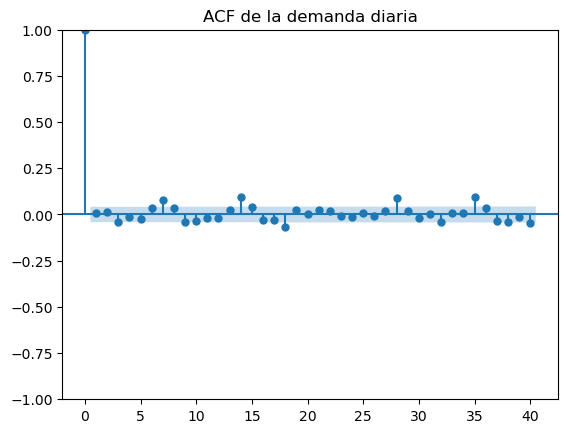

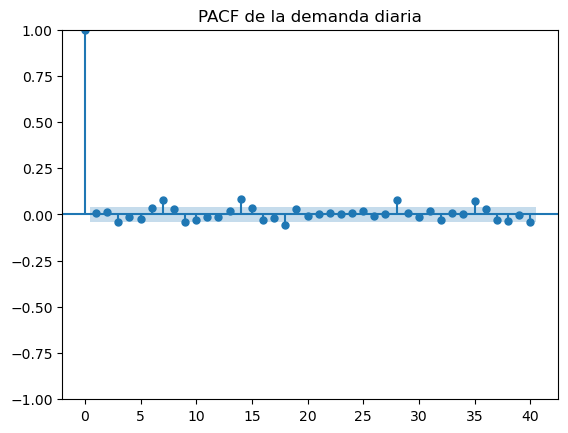

In [17]:
plot_acf(serie.dropna(), lags=40)
plt.title("ACF de la demanda diaria")
plt.show()

plot_pacf(serie.dropna(), lags=40, method="ywm")
plt.title("PACF de la demanda diaria")
plt.show()

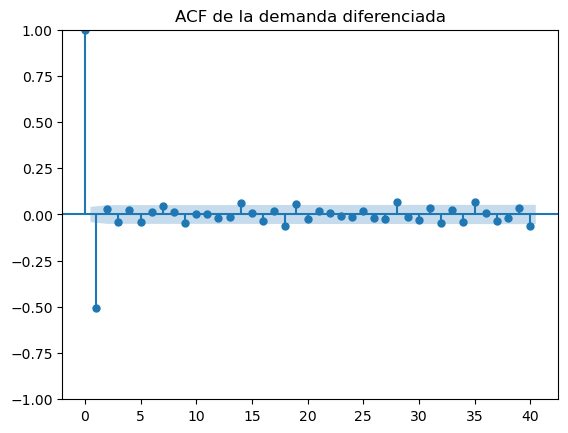

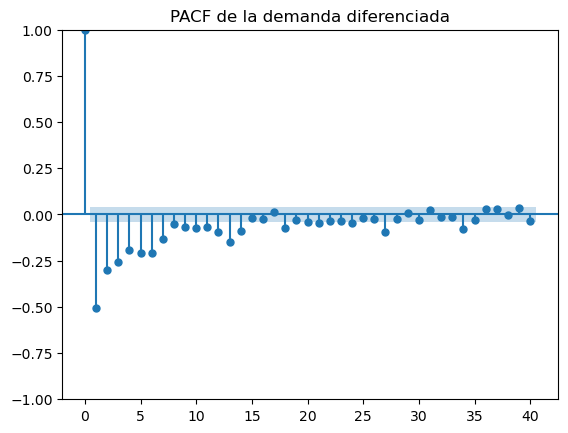

In [18]:
plot_acf(serie_diff, lags=40)
plt.title("ACF de la demanda diferenciada")
plt.show()

plot_pacf(serie_diff, lags=40, method="ywm")
plt.title("PACF de la demanda diferenciada")
plt.show()

Se analizaron las funciones ACF y PACF de la demanda diaria original y de la demanda diferenciada. En la serie original, la mayoría de los rezagos se encuentran cerca de cero, lo que sugiere una autocorrelación débil. Después de aplicar una primera diferencia, la ACF mostró un pico negativo importante en el rezago 1, lo cual sugiere la posible presencia de un componente de media móvil. Por otro lado, la PACF de la serie diferenciada presentó varios rezagos negativos significativos al inicio, sin un corte claro. Con base en este comportamiento, se decidió probar valores pequeños para los parámetros p y q, dejando que la selección final del modelo se determinara mediante métricas de desempeño y diagnóstico de residuales.

In [19]:
h = 90

train = serie.iloc[:-h]
test = serie.iloc[-h:]

In [20]:
p = range(0, 3)
d_values = [1]
q = range(0, 3)

P = range(0, 2)
D = range(0, 2)
Q = range(0, 2)

s = 7

orders = list(itertools.product(p, d_values, q))
seasonal_orders = list(itertools.product(P, D, Q))

In [21]:
resultados = []

for order in orders:
    for seasonal in seasonal_orders:
        
        seasonal_order = seasonal + (s,)
        
        try:
            modelo = sm.tsa.statespace.SARIMAX(
                train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            
            ajuste = modelo.fit(disp=False)
            
            pred = ajuste.forecast(steps=h)
            
            rmse = np.sqrt(mean_squared_error(test, pred))
            mae = mean_absolute_error(test, pred)
            
            resultados.append({
                "order": order,
                "seasonal_order": seasonal_order,
                "AIC": ajuste.aic,
                "BIC": ajuste.bic,
                "RMSE": rmse,
                "MAE": mae
            })
            
        except Exception as e:
            continue

In [22]:
resultados_sarima = pd.DataFrame(resultados)

resultados_sarima = resultados_sarima.sort_values("RMSE").reset_index(drop=True)

resultados_sarima.head(10)

,order,seasonal_order,AIC,BIC,RMSE,MAE
0,"(2, 1, 2)","(1, 1, 1, 7)",19016.172744,19055.865743,20.126403,11.338295
1,"(2, 1, 2)","(0, 1, 1, 7)",18592.289267,18626.311838,20.143350,11.344088
2,"(0, 1, 2)","(1, 0, 1, 7)",18607.614729,18635.983170,20.166872,11.595192
3,"(1, 1, 1)","(1, 0, 1, 7)",18615.660507,18644.031271,20.167195,11.591540
4,"(1, 1, 2)","(0, 1, 1, 7)",18545.209095,18573.561237,20.167631,11.660096
5,"(1, 1, 2)","(1, 0, 1, 7)",18609.390168,18643.432297,20.168311,11.607895
6,"(0, 1, 2)","(1, 1, 1, 7)",18545.597359,18573.949502,20.168553,11.644110
7,"(1, 1, 1)","(1, 1, 1, 7)",18553.833256,18582.187730,20.168722,11.641652
8,"(0, 1, 2)","(0, 1, 1, 7)",18543.638544,18566.320258,20.168757,11.644880
9,"(1, 1, 1)","(0, 1, 1, 7)",18551.961968,18574.645547,20.169119,11.642504


Se dividió la serie en un conjunto de entrenamiento y uno de prueba, utilizando los últimos 90 días para evaluar la capacidad predictiva del modelo. Posteriormente, se definió un espacio de búsqueda para los hiperparámetros SARIMA, considerando p,q∈{0,1,2}, d=1, P,D,Q∈{0,1} y una estacionalidad semanal s=7. Para cada combinación se estimó un modelo SARIMA, se generaron predicciones sobre el periodo de prueba y se calcularon métricas de desempeño como RMSE, MAE, AIC y BIC. El modelo con menor RMSE fue SARIMA(2,1,2)(1,1,1)$_7$
, por lo que se consideró como candidato principal para la predicción de demanda.

In [23]:
mejor_modelo = resultados_sarima.iloc[0]

mejor_order = mejor_modelo["order"]
mejor_seasonal_order = mejor_modelo["seasonal_order"]

print("Mejor order:", mejor_order)
print("Mejor seasonal_order:", mejor_seasonal_order)
print("RMSE:", mejor_modelo["RMSE"])
print("MAE:", mejor_modelo["MAE"])
print("AIC:", mejor_modelo["AIC"])
print("BIC:", mejor_modelo["BIC"])

Mejor order: (2, 1, 2)
Mejor seasonal_order: (1, 1, 1, 7)
RMSE: 20.126403458069152
MAE: 11.338294865648594
AIC: 19016.17274367046
BIC: 19055.865743325794


In [24]:
modelo_final = sm.tsa.statespace.SARIMAX(
    train,
    order=mejor_order,
    seasonal_order=mejor_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

ajuste_final = modelo_final.fit(disp=False)

print(ajuste_final.summary())

                                      SARIMAX Results                                      
Dep. Variable:                             demanda   No. Observations:                 2162
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 7)   Log Likelihood               -9501.086
Date:                             Fri, 15 May 2026   AIC                          19016.173
Time:                                     13:02:55   BIC                          19055.866
Sample:                                 12-30-2019   HQIC                         19030.696
                                      - 11-29-2025                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9837      0.281     -3.505      0.000      -1.534      -0.434
ar.L2         -0.0448      

In [25]:
ljung_box = acorr_ljungbox(
    ajuste_final.resid.dropna(),
    lags=[7, 14, 21, 30],
    return_df=True
)

ljung_box

,lb_stat,lb_pvalue
7,4.455780,0.726035
14,9.133075,0.822432
21,27.321039,0.160478
30,36.225042,0.200802


In [26]:
modelo_alterno = resultados_sarima.iloc[1]

order_alterno = modelo_alterno["order"]
seasonal_order_alterno = modelo_alterno["seasonal_order"]

print("Order alterno:", mejor_order)
print("Alterno seasonal_order:", mejor_seasonal_order)
print("RMSE:", modelo_alterno["RMSE"])
print("MAE:", modelo_alterno["MAE"])
print("AIC:", modelo_alterno["AIC"])
print("BIC:", modelo_alterno["BIC"])

Order alterno: (2, 1, 2)
Alterno seasonal_order: (1, 1, 1, 7)
RMSE: 20.14335038287027
MAE: 11.344088028056579
AIC: 18592.28926659729
BIC: 18626.311837730434


In [27]:
modelo_final_alterno = sm.tsa.statespace.SARIMAX(
    train,
    order=order_alterno,
    seasonal_order=seasonal_order_alterno,
    enforce_stationarity=False,
    enforce_invertibility=False
)

ajuste_final_alterno = modelo_final_alterno.fit(disp=False)

print(ajuste_final_alterno.summary())

                                      SARIMAX Results                                      
Dep. Variable:                             demanda   No. Observations:                 2162
Model:             SARIMAX(2, 1, 2)x(0, 1, [1], 7)   Log Likelihood               -9290.145
Date:                             Fri, 15 May 2026   AIC                          18592.289
Time:                                     13:03:07   BIC                          18626.312
Sample:                                 12-30-2019   HQIC                         18604.738
                                      - 11-29-2025                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8244      0.113     -7.306      0.000      -1.046      -0.603
ar.L2          0.0512      

In [28]:
ljung_box = acorr_ljungbox(
    ajuste_final_alterno.resid.dropna(),
    lags=[7, 14, 21, 30],
    return_df=True
)

ljung_box

,lb_stat,lb_pvalue
7,14.430499,0.044033
14,21.793114,0.082966
21,46.164758,0.001215
30,51.941281,0.007728


Se compararon los modelos con mejor desempeño predictivo y se evaluaron sus residuales mediante la prueba de Ljung-Box. Aunque el modelo SARIMA(2,1,2)(0,1,1)$_7$ presentó menores valores de AIC y BIC, sus residuales mostraron autocorrelación significativa en varios rezagos. En cambio, el modelo SARIMA(2,1,2)(1,1,1)$_7$ obtuvo el menor RMSE y MAE, además de residuales sin autocorrelación significativa según Ljung-Box. Por esta razón, se seleccionó este último como modelo final para generar las predicciones de demanda.

In [29]:
pred_demanda = ajuste_final.forecast(steps=h)

rmse_final = np.sqrt(mean_squared_error(test, pred_demanda))
mae_final = mean_absolute_error(test, pred_demanda)

print("RMSE final:", rmse_final)
print("MAE final:", mae_final)
print("AIC final:", ajuste_final.aic)
print("BIC final:", ajuste_final.bic)

RMSE final: 20.126403458069152
MAE final: 11.338294865648594
AIC final: 19016.17274367046
BIC final: 19055.865743325794


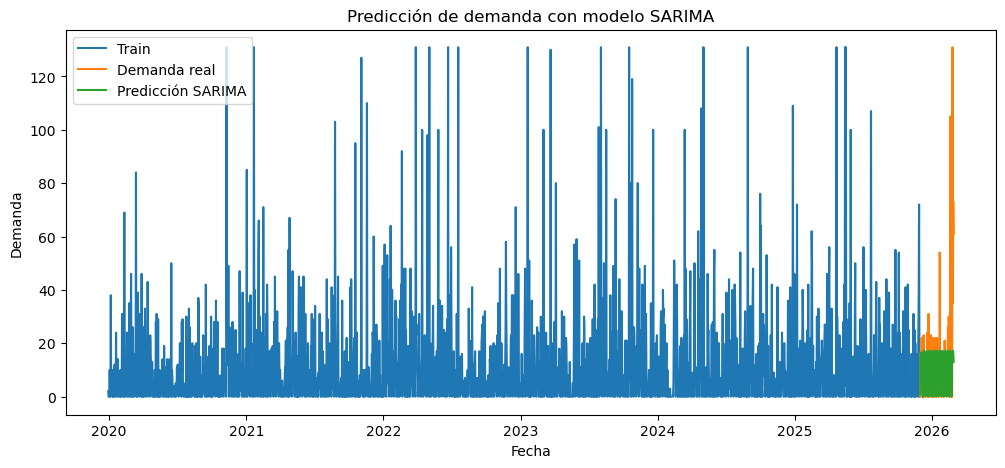

In [30]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Demanda real")
plt.plot(test.index, pred_demanda, label="Predicción SARIMA")
plt.title("Predicción de demanda con modelo SARIMA")
plt.xlabel("Fecha")
plt.ylabel("Demanda")
plt.legend()
plt.show()

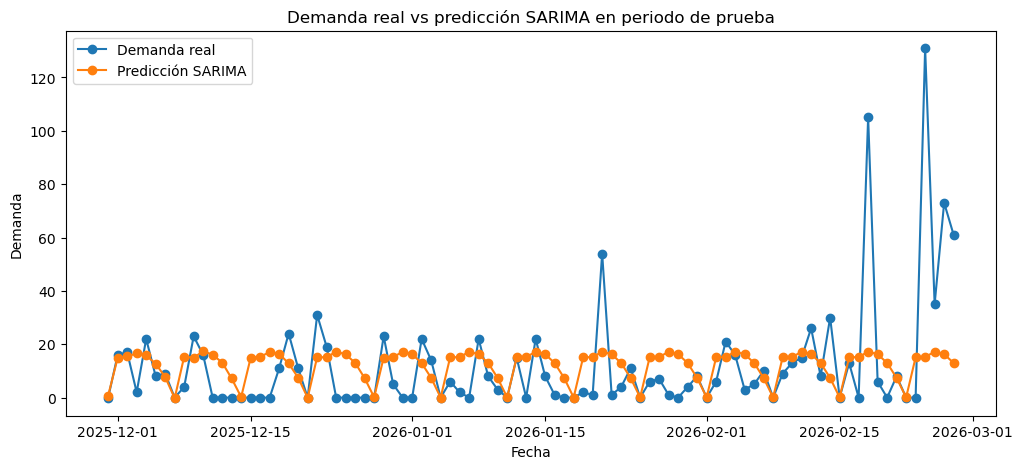

In [31]:
plt.figure(figsize=(12,5))
plt.plot(test.index, test, label="Demanda real", marker="o")
plt.plot(test.index, pred_demanda, label="Predicción SARIMA", marker="o")
plt.title("Demanda real vs predicción SARIMA en periodo de prueba")
plt.xlabel("Fecha")
plt.ylabel("Demanda")
plt.legend()
plt.show()

Una vez seleccionado el modelo SARIMA final, se generaron predicciones para los últimos 90 días de la serie, correspondientes al conjunto de prueba. El modelo obtuvo un RMSE de 20.13 y un MAE de 11.34, lo que indica que la predicción presenta errores moderados, especialmente en días con demanda atípicamente alta. La gráfica del periodo de prueba muestra que el modelo captura el comportamiento promedio y cierto patrón semanal de la demanda, pero no reproduce completamente los picos extremos. Esto es relevante para la etapa de optimización, ya que una subestimación de la demanda puede traducirse en menores niveles de inventario óptimo y mayores faltantes al comparar contra la demanda real.

In [32]:
resultados_prediccion = pd.DataFrame({
    "fecha": test.index,
    "demanda_real": test.values,
    "demanda_predicha": pred_demanda.values
})

resultados_prediccion.head()

resultados_prediccion["demanda_predicha"] = resultados_prediccion["demanda_predicha"].clip(lower=0)

In [33]:
demanda_predicha = pred_demanda.clip(lower=0).values

datos_opt = demanda_diaria.iloc[-h:].copy()

datos_opt["demanda_predicha"] = demanda_predicha

In [34]:
d_hat = datos_opt["demanda_predicha"].values
p_t = datos_opt["costo_unitario"].values
precio = datos_opt["precio_unitario"].values

n = len(d_hat)

ch = 0.05 * p_t
cs = precio - p_t

cs = np.maximum(cs, 0)

C = datos_opt["demanda_predicha"].quantile(0.95)
B = np.sum(p_t * d_hat)

In [35]:
x = cp.Variable(n)

holding_cost = cp.multiply(ch, cp.pos(x - d_hat))
shortage_cost = cp.multiply(cs, cp.pos(d_hat - x))

objective = cp.Minimize(cp.sum(holding_cost + shortage_cost))

constraints = [
    x >= 0,
    x <= C,
    cp.sum(cp.multiply(p_t, x)) <= B
]

problem = cp.Problem(objective, constraints)
problem.solve()

print("Estado del modelo:", problem.status)
print("Costo óptimo:", problem.value)

Estado del modelo: optimal
Costo óptimo: 19.76957040174589


In [36]:
resultados_optimizacion = pd.DataFrame({
    "fecha": datos_opt.index,
    "demanda_real": datos_opt["demanda_original"].values,
    "demanda_ajustada": datos_opt["demanda"].values,
    "demanda_predicha": d_hat,
    "inventario_optimo": x.value,
    "costo_unitario": p_t,
    "precio_unitario": precio
})

In [37]:
resultados_optimizacion["faltante"] = np.maximum(
    resultados_optimizacion["demanda_real"] - resultados_optimizacion["inventario_optimo"],
    0
)

resultados_optimizacion["exceso_inventario"] = np.maximum(
    resultados_optimizacion["inventario_optimo"] - resultados_optimizacion["demanda_real"],
    0
)
resultados_optimizacion["costo_mantenimiento"] = (
    0.05 * resultados_optimizacion["costo_unitario"] *
    resultados_optimizacion["exceso_inventario"]
)

resultados_optimizacion["costo_desabasto"] = (
    np.maximum(resultados_optimizacion["precio_unitario"] - resultados_optimizacion["costo_unitario"], 0) *
    resultados_optimizacion["faltante"]
)

resultados_optimizacion["costo_total_realizado"] = (
    resultados_optimizacion["costo_mantenimiento"] +
    resultados_optimizacion["costo_desabasto"]
)

resultados_optimizacion.head()

,fecha,demanda_real,demanda_ajustada,demanda_predicha,inventario_optimo,costo_unitario,precio_unitario,faltante,exceso_inventario,costo_mantenimiento,costo_desabasto,costo_total_realizado
0,2025-11-30,0.0,0.0,0.791183,0.791183,123.56,196.000,0.000000,0.791183,4.887931,0.000000,4.887931
1,2025-12-01,16.0,16.0,14.887106,14.887106,123.56,174.435,1.112894,0.000000,0.000000,56.618462,56.618462
2,2025-12-02,17.0,17.0,15.442070,15.442070,123.56,186.000,1.557930,0.000000,0.000000,97.277155,97.277155
3,2025-12-03,2.0,2.0,16.568672,16.568672,123.56,186.000,0.000000,14.568672,90.005255,0.000000,90.005255
4,2025-12-04,22.0,22.0,15.799770,15.799770,123.56,179.435,6.200230,0.000000,0.000000,346.437874,346.437874


In [38]:
resumen = pd.DataFrame({
    "Métrica": [
        "Costo óptimo esperado",
        "Inventario óptimo promedio",
        "Demanda real promedio",
        "Demanda predicha promedio",
        "Faltante promedio",
        "Exceso promedio",
        "Presupuesto utilizado"
    ],
    "Valor": [
        problem.value,
        resultados_optimizacion["inventario_optimo"].mean(),
        resultados_optimizacion["demanda_real"].mean(),
        resultados_optimizacion["demanda_predicha"].mean(),
        resultados_optimizacion["faltante"].mean(),
        resultados_optimizacion["exceso_inventario"].mean(),
        np.sum(p_t * resultados_optimizacion["inventario_optimo"])
    ]
})

resumen["Valor"] = resumen["Valor"].round(2)
resumen

,Métrica,Valor
0,Costo óptimo esperado,19.77
1,Inventario óptimo promedio,12.06
2,Demanda real promedio,20.50
3,Demanda predicha promedio,12.07
4,Faltante promedio,14.26
5,Exceso promedio,5.83
6,Presupuesto utilizado,134138.45


En esta etapa se utilizó la demanda predicha por el modelo SARIMA como entrada del modelo de optimización convexa. La variable de decisión fue el inventario óptimo diario x$_t$, y la función objetivo minimizó los costos asociados al exceso de inventario y al desabasto. El modelo incorporó restricciones de no negatividad, capacidad máxima y presupuesto. CVXPY encontró una solución óptima factible, con un costo óptimo esperado de 19.77. El inventario óptimo promedio fue de 12.06 unidades, muy cercano a la demanda predicha promedio de 12.07 unidades. Sin embargo, la demanda real promedio fue de 20.50 unidades, lo que generó un faltante promedio de 14.26 unidades. Esto muestra que la política de inventario depende fuertemente de la calidad de la predicción de demanda.

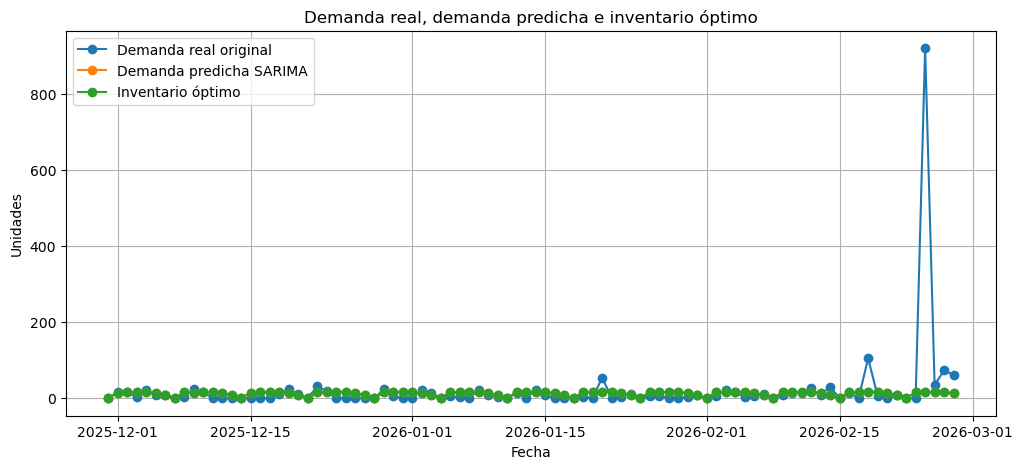

In [39]:
plt.figure(figsize=(12,5))

plt.plot(
    resultados_optimizacion["fecha"],
    resultados_optimizacion["demanda_real"],
    label="Demanda real original",
    marker="o"
)

plt.plot(
    resultados_optimizacion["fecha"],
    resultados_optimizacion["demanda_predicha"],
    label="Demanda predicha SARIMA",
    marker="o"
)

plt.plot(
    resultados_optimizacion["fecha"],
    resultados_optimizacion["inventario_optimo"],
    label="Inventario óptimo",
    marker="o"
)

plt.title("Demanda real, demanda predicha e inventario óptimo")
plt.xlabel("Fecha")
plt.ylabel("Unidades")
plt.legend()
plt.grid(True)
plt.show()

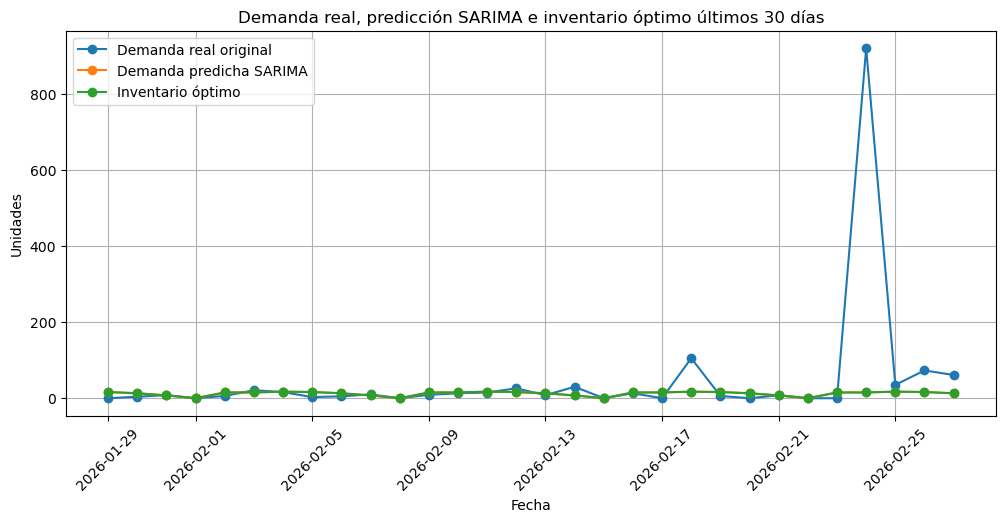

In [40]:
ultimos_dias = resultados_optimizacion.tail(30)

plt.figure(figsize=(12,5))

plt.plot(
    ultimos_dias["fecha"],
    ultimos_dias["demanda_real"],
    label="Demanda real original",
    marker="o"
)

plt.plot(
    ultimos_dias["fecha"],
    ultimos_dias["demanda_predicha"],
    label="Demanda predicha SARIMA",
    marker="o"
)

plt.plot(
    ultimos_dias["fecha"],
    ultimos_dias["inventario_optimo"],
    label="Inventario óptimo",
    marker="o"
)

plt.title("Demanda real, predicción SARIMA e inventario óptimo últimos 30 días")
plt.xlabel("Fecha")
plt.ylabel("Unidades")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

La gráfica compara la demanda real original, la demanda predicha por SARIMA y el inventario óptimo calculado por el modelo convexo. Se observa que el inventario óptimo sigue muy de cerca a la demanda predicha, lo cual es consistente con la formulación del modelo, ya que la predicción funciona como entrada principal de la optimización. Sin embargo, la demanda real presenta picos extremos que no fueron anticipados por el modelo SARIMA. Esto indica que, aunque la política óptima es adecuada respecto a la demanda estimada, puede generar faltantes importantes cuando ocurren eventos atípicos o pedidos extraordinarios.

In [41]:
import cvxpy as cp
import numpy as np
import pandas as pd

def resolver_modelo_inventario(datos, columna_demanda_modelo, nombre_modelo):
    d_hat = datos[columna_demanda_modelo].values
    p_t = datos["costo_unitario"].values
    precio = datos["precio_unitario"].values
    
    n = len(d_hat)
    
    ch = 0.05 * p_t
    cs = precio - p_t
    cs = np.maximum(cs, 0)
    
    C = datos[columna_demanda_modelo].quantile(0.95)
    B = np.sum(p_t * d_hat)
    
    x = cp.Variable(n)
    
    holding_cost = cp.multiply(ch, cp.pos(x - d_hat))
    shortage_cost = cp.multiply(cs, cp.pos(d_hat - x))
    
    objective = cp.Minimize(cp.sum(holding_cost + shortage_cost))
    
    constraints = [
        x >= 0,
        x <= C,
        cp.sum(cp.multiply(p_t, x)) <= B
    ]
    
    problem = cp.Problem(objective, constraints)
    problem.solve()
    
    resultados = pd.DataFrame({
        "fecha": datos.index,
        "modelo": nombre_modelo,
        "demanda_real": datos["demanda_original"].values,
        "demanda_ajustada": datos["demanda"].values,
        "demanda_usada_modelo": d_hat,
        "inventario_optimo": x.value,
        "costo_unitario": p_t,
        "precio_unitario": precio
    })
    
    resultados["faltante"] = np.maximum(
        resultados["demanda_real"] - resultados["inventario_optimo"],
        0
    )
    
    resultados["exceso_inventario"] = np.maximum(
        resultados["inventario_optimo"] - resultados["demanda_real"],
        0
    )
    
    resultados["costo_mantenimiento"] = (
        0.05 * resultados["costo_unitario"] *
        resultados["exceso_inventario"]
    )
    
    resultados["costo_desabasto"] = (
        np.maximum(
            resultados["precio_unitario"] - resultados["costo_unitario"],
            0
        ) * resultados["faltante"]
    )
    
    resultados["costo_total_realizado"] = (
        resultados["costo_mantenimiento"] +
        resultados["costo_desabasto"]
    )
    
    resumen = pd.DataFrame({
        "Modelo": [nombre_modelo] * 8,
        "Métrica": [
            "Costo óptimo esperado",
            "Costo total realizado",
            "Inventario óptimo promedio",
            "Demanda real promedio",
            "Demanda usada por el modelo promedio",
            "Faltante promedio",
            "Exceso promedio",
            "Presupuesto utilizado"
        ],
        "Valor": [
            problem.value,
            resultados["costo_total_realizado"].sum(),
            resultados["inventario_optimo"].mean(),
            resultados["demanda_real"].mean(),
            resultados["demanda_usada_modelo"].mean(),
            resultados["faltante"].mean(),
            resultados["exceso_inventario"].mean(),
            np.sum(p_t * resultados["inventario_optimo"])
        ]
    })
    
    resumen["Valor"] = resumen["Valor"].round(2)
    
    return resultados, resumen

In [45]:
h = 90

datos_comparacion = demanda_diaria.iloc[-h:].copy()

datos_comparacion["demanda_predicha"] = pred_demanda.clip(lower=0).values

resultados_predicha, resumen_predicha = resolver_modelo_inventario(
    datos=datos_comparacion,
    columna_demanda_modelo="demanda_predicha",
    nombre_modelo="Optimización con demanda predicha SARIMA"
)

resultados_historica, resumen_historica = resolver_modelo_inventario(
    datos=datos_comparacion,
    columna_demanda_modelo="demanda_original",
    nombre_modelo="Optimización con demanda real histórica"
)

resumen_comparativo = pd.concat(
    [resumen_predicha, resumen_historica],
    ignore_index=True
)


In [46]:
tabla_comparativa = resumen_comparativo.pivot(
    index="Métrica",
    columns="Modelo",
    values="Valor"
)

tabla_comparativa

Modelo,Optimización con demanda predicha SARIMA,Optimización con demanda real histórica
Métrica,,
Costo total realizado,83340.73,61019.99
Costo óptimo esperado,19.77,61019.99
Demanda real promedio,20.50,20.50
Demanda usada por el modelo promedio,12.07,20.50
Exceso promedio,5.83,0.00
Faltante promedio,14.26,10.94
Inventario óptimo promedio,12.06,9.56
Presupuesto utilizado,134138.45,106264.98


El modelo con SARIMA es más realista para determinar el inventario óptimo porque utiliza una predicción de demanda futura, que es la información disponible antes de tomar decisiones operativas. En cambio, el modelo con demanda histórica utiliza valores reales ya observados, por lo que funciona como un escenario ideal de referencia. Si se usara únicamente la demanda histórica para definir el inventario, se estaría suponiendo que la tienda conoce de antemano la demanda futura, lo cual no ocurre en la práctica. Por ello, la combinación SARIMA + optimización convexa permite construir una política de inventario más aplicable a la planeación real, aunque su desempeño depende de la calidad de la predicción.

## Insights clave
* El modelo SARIMA está prediciendo una demanda promedio menor que la demanda real observada. Por eso, el modelo convexo recomienda un inventario promedio cercano a la demanda predicha, pero al compararlo contra la demanda real aparecen faltantes importantes.

* El modelo de optimización convexa logró encontrar una solución factible y óptima para el problema de inventario, como se observa en el estado optimal. Esto indica que el solver pudo minimizar exitosamente la función objetivo considerando los costos de mantenimiento de inventario y los costos asociados al desabasto, bajo las restricciones de no negatividad, capacidad de almacenamiento y presupuesto. En esta nueva etapa, la demanda utilizada dentro del modelo convexo ya no corresponde a la demanda histórica observada, sino a la demanda predicha por el modelo SARIMA. Por ello, el modelo de optimización toma decisiones de inventario con base en una estimación futura de la demanda, lo cual representa mejor un escenario real de planeación.

* El costo óptimo esperado obtenido fue de aproximadamente 19.77. Este valor representa el mínimo de la función objetivo bajo la demanda predicha y las restricciones establecidas. No debe interpretarse como el gasto monetario total real de operación, sino como el valor óptimo del criterio de penalización definido en el modelo.

* El inventario óptimo promedio calculado por el modelo fue de 12.06 unidades, valor muy cercano a la demanda predicha promedio de 12.07 unidades. Esto indica que el modelo convexo está ajustando el inventario principalmente alrededor de la demanda estimada por SARIMA.

* La demanda real promedio durante el periodo evaluado fue de 20.50 unidades, mientras que la demanda predicha promedio fue de 12.07 unidades. Esta diferencia muestra que el modelo SARIMA subestimó la demanda real en el periodo de prueba.

* Debido a que la demanda predicha fue menor que la demanda real, el faltante promedio aumentó a 14.26 unidades. Esto significa que, aunque la política de inventario es óptima respecto a la demanda estimada, al compararla contra la demanda real observada se generan faltantes importantes.

* El exceso promedio de inventario fue de 5.83 unidades. A diferencia del modelo anterior, donde el exceso era prácticamente cero, ahora sí aparecen días donde el inventario óptimo supera la demanda real. Esto puede ocurrir porque la demanda real diaria es muy irregular: algunos días presenta valores bajos o cercanos a cero, mientras que otros días tiene picos altos difíciles de anticipar.

* El presupuesto utilizado fue aproximadamente de 134,138.45. Este valor representa el costo agregado de adquirir el inventario recomendado por el modelo durante el periodo de prueba, usando los costos unitarios registrados.

* La comparación entre demanda real, demanda predicha e inventario óptimo muestra que la calidad de la predicción tiene un impacto directo sobre la política de inventario. Si el modelo predictivo subestima la demanda, el modelo convexo tenderá a recomendar niveles bajos de inventario, lo que puede incrementar los faltantes.

* Se identificó una cantidad considerable de registros con existencia negativa, lo cual sugiere la presencia recurrente de pedidos realizados sin inventario disponible inmediato. Esto puede interpretarse como evidencia de posibles eventos de backorder o problemas de registro en el sistema.

* En conjunto, los resultados muestran que el modelo convexo funciona correctamente, pero su desempeño operativo depende fuertemente de la precisión del modelo SARIMA. La política obtenida es óptima respecto a la demanda predicha, pero al evaluar contra la demanda real se observa que la subestimación de la demanda genera un nivel considerable de faltantes.

In [15]:
negativos = (df['EXISTENCIA'] < 0).sum()

positivos = (df['EXISTENCIA'] > 0).sum()

ceros = (df['EXISTENCIA'] == 0).sum()

print(f"Registros con existencia negativa: {negativos}")
print(f"Registros con existencia positiva: {positivos}")
print(f"Registros con existencia en cero: {ceros}")

Registros con existencia negativa: 1087
Registros con existencia positiva: 2156
Registros con existencia en cero: 6


* Se identificó una cantidad considerable de registros historicos con existencia negativa, lo que sugiere la presencia recurrente de pedidos realizados sin inventario disponible inmediato.

## Sugerencias:
1. Mantener como inventario base un nivel cercano a la demanda predicha por el modelo SARIMA. En el periodo evaluado, el inventario óptimo promedio fue de aproximadamente 12.06 unidades, muy cercano a la demanda predicha promedio de 12.07 unidades. Sin embargo, este valor debe interpretarse como una recomendación base, no como un nivel fijo definitivo.
2. Incorporar un inventario de seguridad adicional, ya que la demanda real promedio fue de 20.50 unidades, mientras que la demanda predicha promedio fue de 12.07 unidades. Esta diferencia indica que el modelo tiende a subestimar la demanda real, por lo que mantener únicamente el inventario óptimo calculado puede generar faltantes importantes.
3. Revisar la política de inventario cuando existan picos de demanda. El faltante promedio fue de 14.26 unidades, lo que sugiere que algunos días la demanda real supera considerablemente al inventario recomendado. Por ello, se recomienda identificar días, semanas o temporadas con alta demanda para reforzar el inventario antes de esos periodos.
4. Planificar financieramente considerando que el presupuesto utilizado por la política óptima fue de aproximadamente 134,138.45 para el periodo evaluado. Este valor representa el costo agregado estimado de adquirir el inventario recomendado por el modelo, utilizando los costos unitarios registrados.
5. Implementar alertas automáticas cuando el inventario alcance niveles críticos o negativos. La presencia de existencias negativas sugiere posibles eventos de backorder o ventas realizadas sin disponibilidad inmediata, lo cual puede afectar la satisfacción del cliente y generar ventas perdidas.
6. Analizar individualmente los días con demandas extremadamente altas, ya que podrían corresponder a compras atípicas, pedidos especiales, errores de captura o proyectos grandes de clientes. Estos eventos no siempre son capturados por un modelo SARIMA, por lo que pueden requerir una regla operativa adicional.
7. Mantener una política mixta: usar el modelo SARIMA para estimar la demanda base y el modelo convexo para calcular el inventario óptimo, pero ajustar la decisión final con inventario de seguridad en periodos de alta variabilidad. Esto permite balancear costos de almacenamiento y riesgo de desabasto.
8. Evaluar periódicamente el desempeño del modelo predictivo. Si la demanda real continúa siendo mayor que la predicha, se recomienda actualizar el modelo SARIMA, probar otros horizontes de predicción o incorporar variables adicionales como promociones, pedidos especiales, días de la semana o temporadas de construcción.
9. Priorizar la reducción de faltantes sobre la reducción absoluta del exceso. En los resultados actuales, el exceso promedio fue de 5.83 unidades, mientras que el faltante promedio fue de 14.26 unidades. Esto sugiere que el costo operativo de no tener producto disponible podría ser más relevante que el costo de mantener algunas unidades adicionales en inventario.

## Conclusiones:
El presente proyecto permitió integrar un modelo predictivo de series de tiempo con un modelo de optimización convexa para abordar un problema real de inventario en una tienda de pinturas. A partir de datos históricos de demanda diaria, se estimó un modelo SARIMA con el objetivo de predecir la demanda futura y posteriormente utilizar dichas predicciones como entrada en un modelo tipo Newsvendor para determinar el nivel óptimo de inventario.

Los resultados muestran que el modelo convexo ajusta el inventario óptimo alrededor de la demanda predicha. En el periodo evaluado, el inventario óptimo promedio fue de aproximadamente 12.06 unidades, muy cercano a la demanda predicha promedio de 12.07 unidades. Sin embargo, la demanda real promedio fue de 20.50 unidades, lo cual indica que el modelo SARIMA subestimó la demanda real durante el periodo de prueba.

Esta diferencia entre demanda predicha y demanda real tuvo un impacto directo en la política de inventario. Aunque el modelo convexo encontró una solución óptima respecto a la demanda estimada, al compararla contra la demanda real se observaron faltantes promedio de 14.26 unidades y exceso promedio de 5.83 unidades. Esto evidencia que la calidad del modelo predictivo es fundamental para que la política de inventario sea efectiva en la práctica.

El proyecto permite concluir que la optimización convexa es una herramienta útil para diseñar políticas de inventario bajo restricciones operativas y financieras. Sin embargo, también muestra que el desempeño final depende fuertemente de la precisión de la predicción de demanda. Si el modelo predictivo subestima la demanda, el inventario recomendado puede ser insuficiente y generar faltantes relevantes.